# Chess Influence Fields — Interactive Exploration

This notebook lets you explore the temporal influence fields for any chess position.

**Fields computed:**
- `Φ_white(x)` — aggregate white influence on square x
- `Φ_black(x)` — aggregate black influence on square x  
- `C(x) = Φ_white(x) - Φ_black(x)` — control field

**Influence decay:** `φ_i(x) = α^(τ_i(x))` where τ is the BFS distance.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from chess_fields import compute_fields_from_fen, fen_to_board
from visualize import plot_all_fields, plot_control_field, plot_piece_influence, plot_alpha_comparison

## 1. Starting position

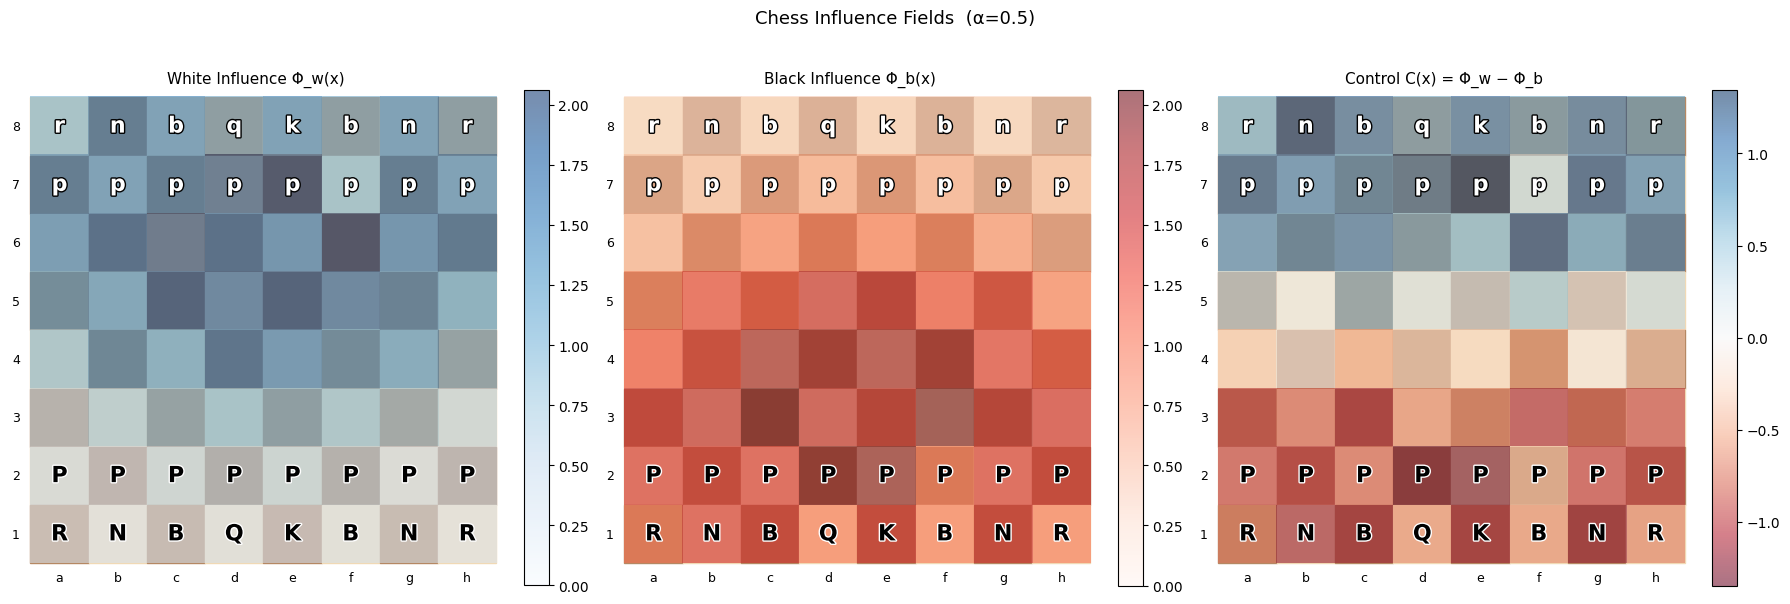

Max |C(x)|: 1.3438


In [2]:
STARTING = 'rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1'

fig = plot_all_fields(STARTING, alpha=0.5)
plt.show()

# Should be roughly symmetric
fields = compute_fields_from_fen(STARTING)
print('Max |C(x)|:', np.abs(fields['control']).max().round(4))

## 2. After 1.e4 — white opens the centre

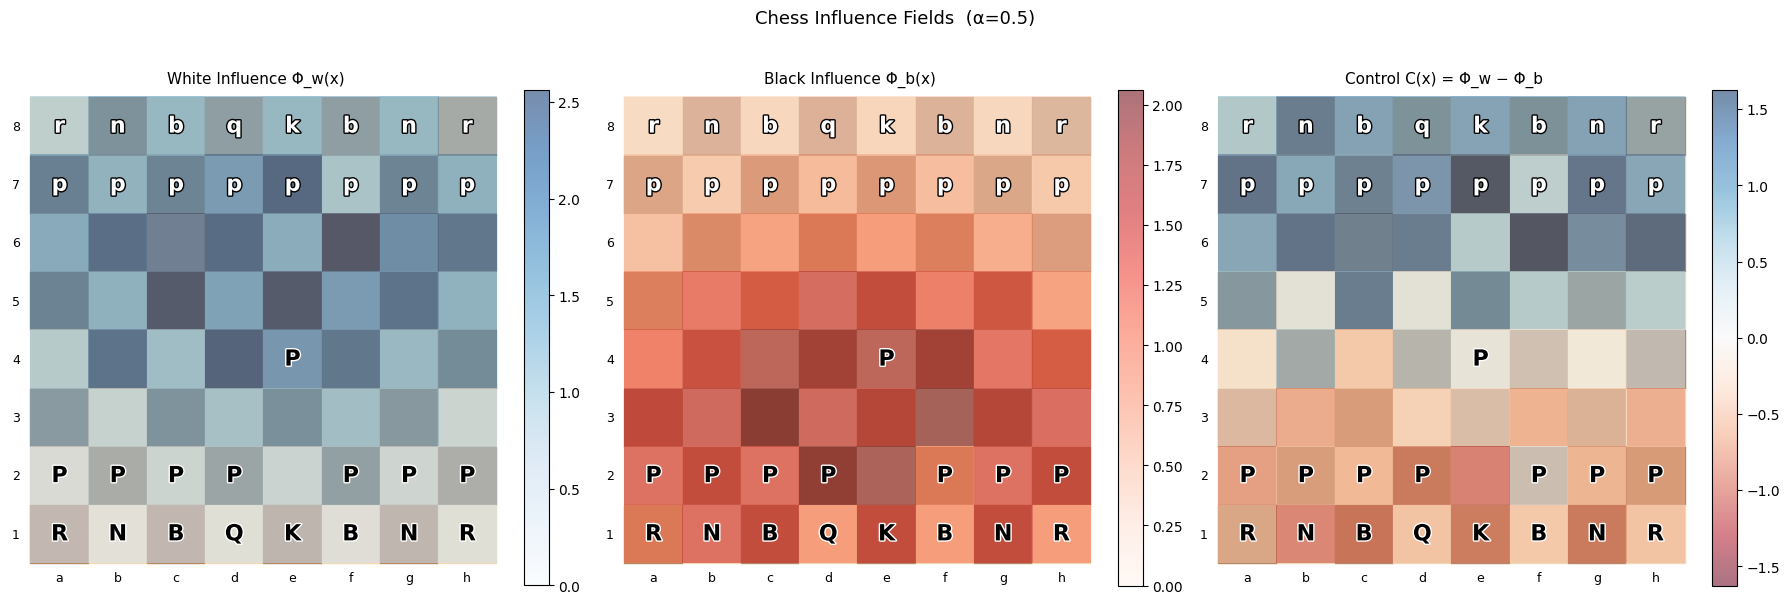

In [3]:
E4 = 'rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq e3 0 1'

fig = plot_all_fields(E4, alpha=0.5)
plt.show()

## 3. Influence of a single piece

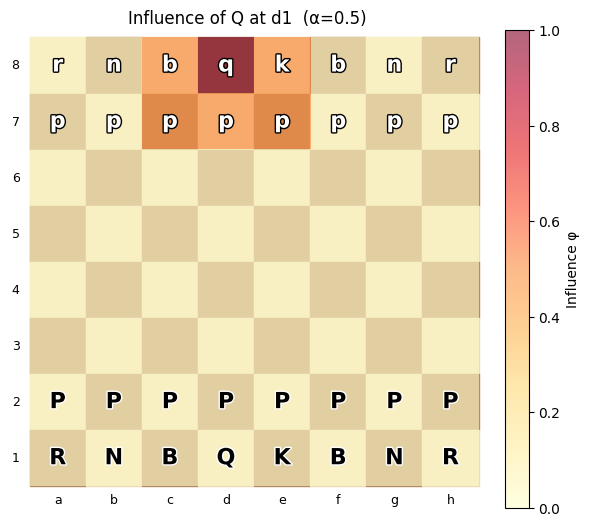

In [4]:
# White queen on d1 = row 7, col 3
fig = plot_piece_influence(STARTING, piece_square=(7, 3), alpha=0.5)
plt.show()

## 4. Effect of α

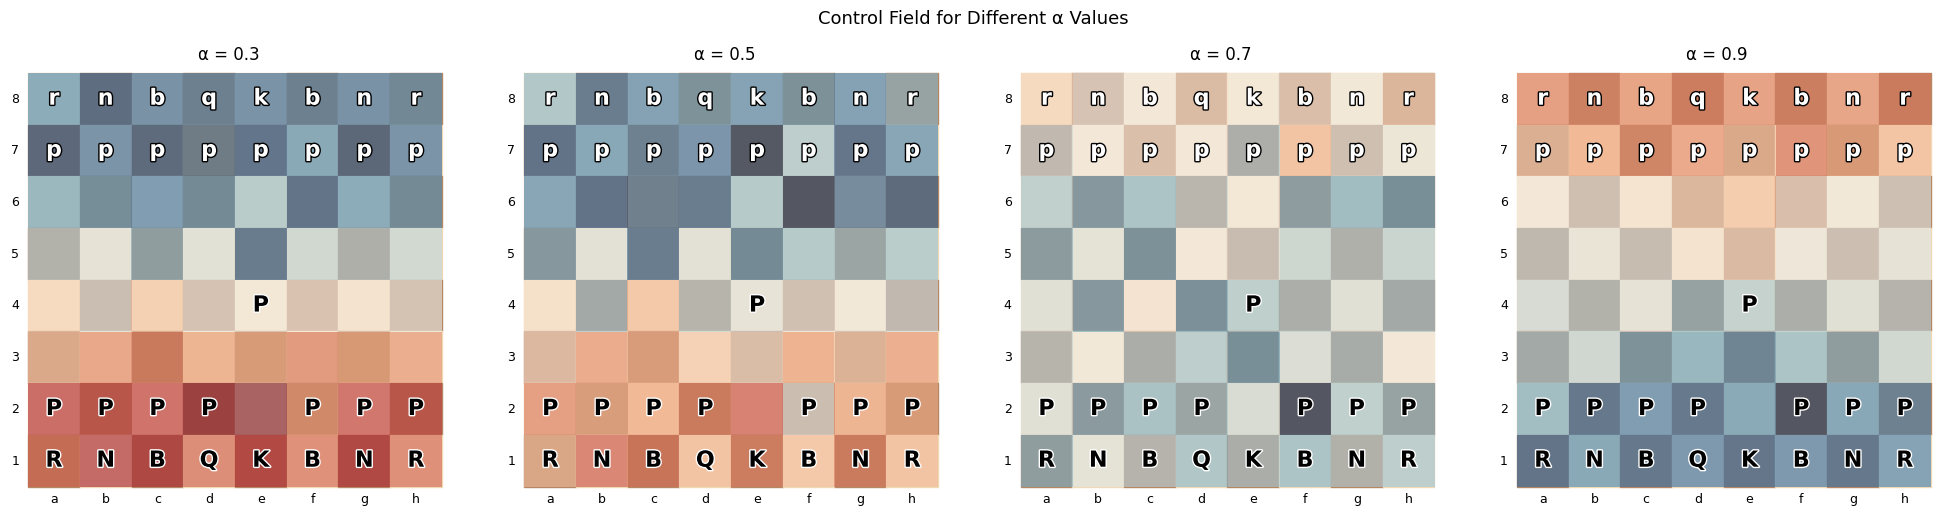

In [5]:
fig = plot_alpha_comparison(E4, alphas=[0.3, 0.5, 0.7, 0.9])
plt.show()

# Observation:
# Low α  → only nearby squares matter (sharp, local)
# High α → distant pieces still have significant influence (diffuse, global)

## 5. Try your own FEN

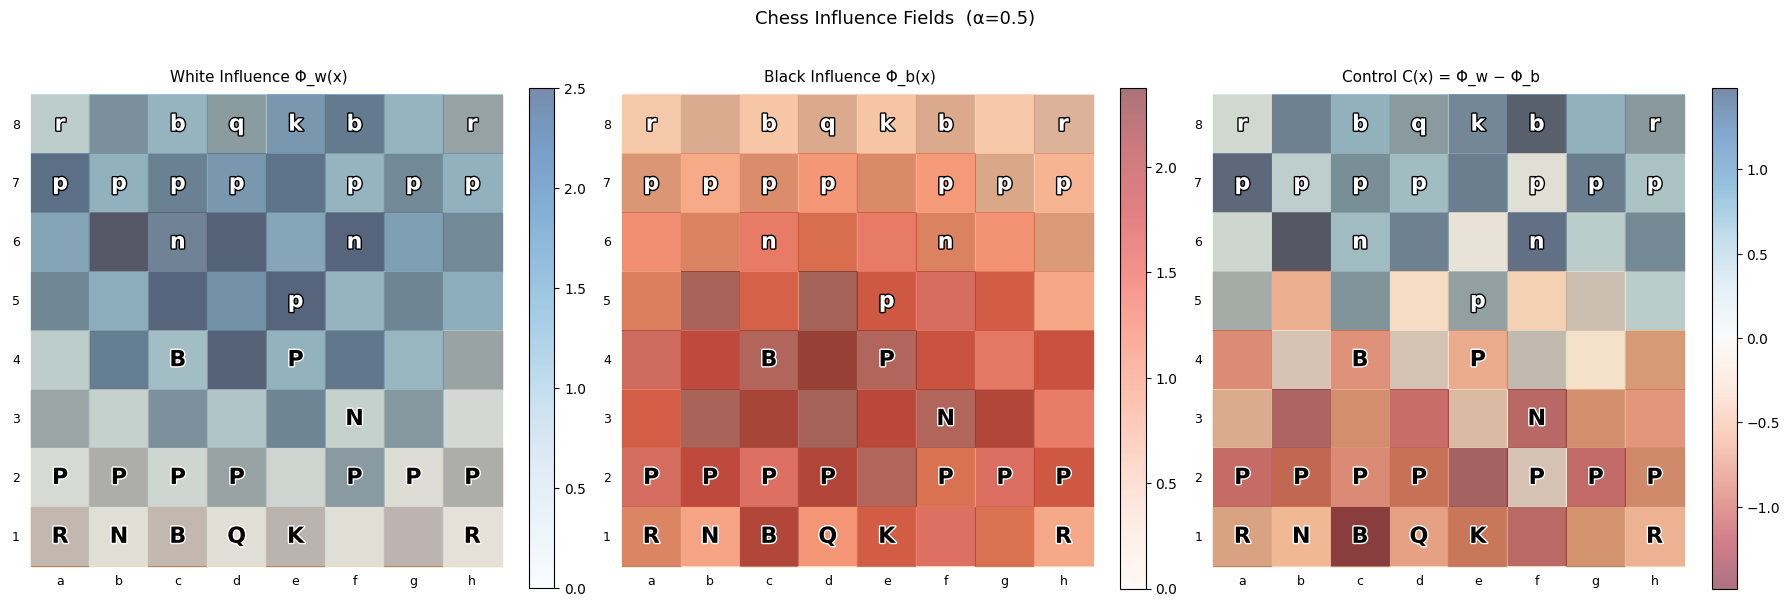

Squares where white is dominant (C > 0.5):
  a4: 0.562
  c4: 0.812
  e4: 0.688
  h4: 0.594
  b3: 1.469
  c3: 0.781
  d3: 1.031
  f3: 1.219
  g3: 0.594
  h3: 0.906
  a2: 1.297
  b2: 0.578
  c2: 0.859
  d2: 0.766
  e2: 1.078
  g2: 1.078
  h2: 0.703
  b1: 1.023
  c1: 0.883
  d1: 0.742
  e1: 1.367
  f1: 1.383
  g1: 0.898
  h1: 0.758


In [6]:
# Paste any FEN here
MY_FEN = 'r1bqkb1r/pppp1ppp/2n2n2/4p3/2B1P3/5N2/PPPP1PPP/RNBQK2R w KQkq - 4 4'  # Italian game

fig = plot_all_fields(MY_FEN, alpha=0.5)
plt.show()

fields = compute_fields_from_fen(MY_FEN)
C = fields['control']
print('Squares where white is dominant (C > 0.5):')
for r in range(8):
    for c in range(8):
        if C[r,c] > 0.5:
            print(f"  {'abcdefgh'[c]}{8-r}: {C[r,c]:.3f}")

## 6. Batch processing — check a sample of your 2.5M positions

In [7]:
from chess_fields import compute_fields_batch, compute_full_features_batch

# -----------------------------------------------------------------------
# Load your FENs — adjust path and loading logic to your format
# -----------------------------------------------------------------------
# Example: if you have a text file with one FEN per line
# with open('your_fens.txt') as f:
#     all_fens = [line.strip().split()[0] for line in f]  # take FEN part only

# For now, test with a small synthetic batch
test_fens = [
    'rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1',
    'rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq e3 0 1',
    'r1bqkb1r/pppp1ppp/2n2n2/4p3/2B1P3/5N2/PPPP1PPP/RNBQK2R w KQkq - 4 4',
]

# Single channel: C(x) only — shape (N, 64)
X_control = compute_fields_batch(test_fens, alpha=0.5, flatten=True)
print('Control field batch shape:', X_control.shape)

# Three channels: white, black, control — shape (N, 3, 64)
X_full = compute_full_features_batch(test_fens, alpha=0.5, flatten=True)
print('Full features batch shape:', X_full.shape)

Control field batch shape: (3, 64)
Full features batch shape: (3, 3, 64)


## 7. Benchmark: speed on large batches

In [8]:
import time

# Generate dummy FENs for speed test
bench_fens = test_fens * 100  # 300 positions

t0 = time.time()
X = compute_fields_batch(bench_fens, alpha=0.5)
elapsed = time.time() - t0

print(f'{len(bench_fens)} positions in {elapsed:.2f}s')
print(f'→ {len(bench_fens)/elapsed:.0f} positions/sec')
print(f'→ Estimated time for 2.5M: {2_500_000 / (len(bench_fens)/elapsed) / 3600:.1f} hours')
print()
print('If too slow → consider multiprocessing or numba JIT on bfs_distances')

300 positions in 0.57s
→ 529 positions/sec
→ Estimated time for 2.5M: 1.3 hours

If too slow → consider multiprocessing or numba JIT on bfs_distances


## 8. Correlation with material balance

In [9]:
PIECE_VALUES = {1:1, 2:3, 3:3, 4:5, 5:9, 6:0}  # P N B R Q K

def material_balance(fen):
    from chess_fields import fen_to_board
    board = fen_to_board(fen)
    score = 0
    for r in range(8):
        for c in range(8):
            p = board[r, c]
            if p != 0:
                score += np.sign(p) * PIECE_VALUES[abs(p)]
    return score

def total_control(fen, alpha=0.5):
    fields = compute_fields_from_fen(fen, alpha=alpha)
    return fields['control'].sum()

fens_to_compare = [
    ('Starting',   'rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1'),
    ('After 1.e4', 'rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq e3 0 1'),
    ('Italian',    'r1bqkb1r/pppp1ppp/2n2n2/4p3/2B1P3/5N2/PPPP1PPP/RNBQK2R w KQkq - 4 4'),
]

print(f'{"Position":<12} {"Material":>10} {"Ctrl Sum":>10}')
print('-' * 35)
for name, fen in fens_to_compare:
    m = material_balance(fen)
    ctrl = total_control(fen)
    print(f'{name:<12} {m:>10.1f} {ctrl:>10.3f}')

Position       Material   Ctrl Sum
-----------------------------------
Starting            0.0      0.000
After 1.e4          0.0     19.250
Italian             0.0     -1.703
